# <font color='blue'> Comparing Regression Models </font>

# <font color='orange'> Logistic Regression </font>

In [1]:
# load the data
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Logistic Regression Performance
Accuracy : 0.9755
Precision: 0.0610
Recall   : 0.9184
F1 Score : 0.1144
ROC-AUC  : 0.9721

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



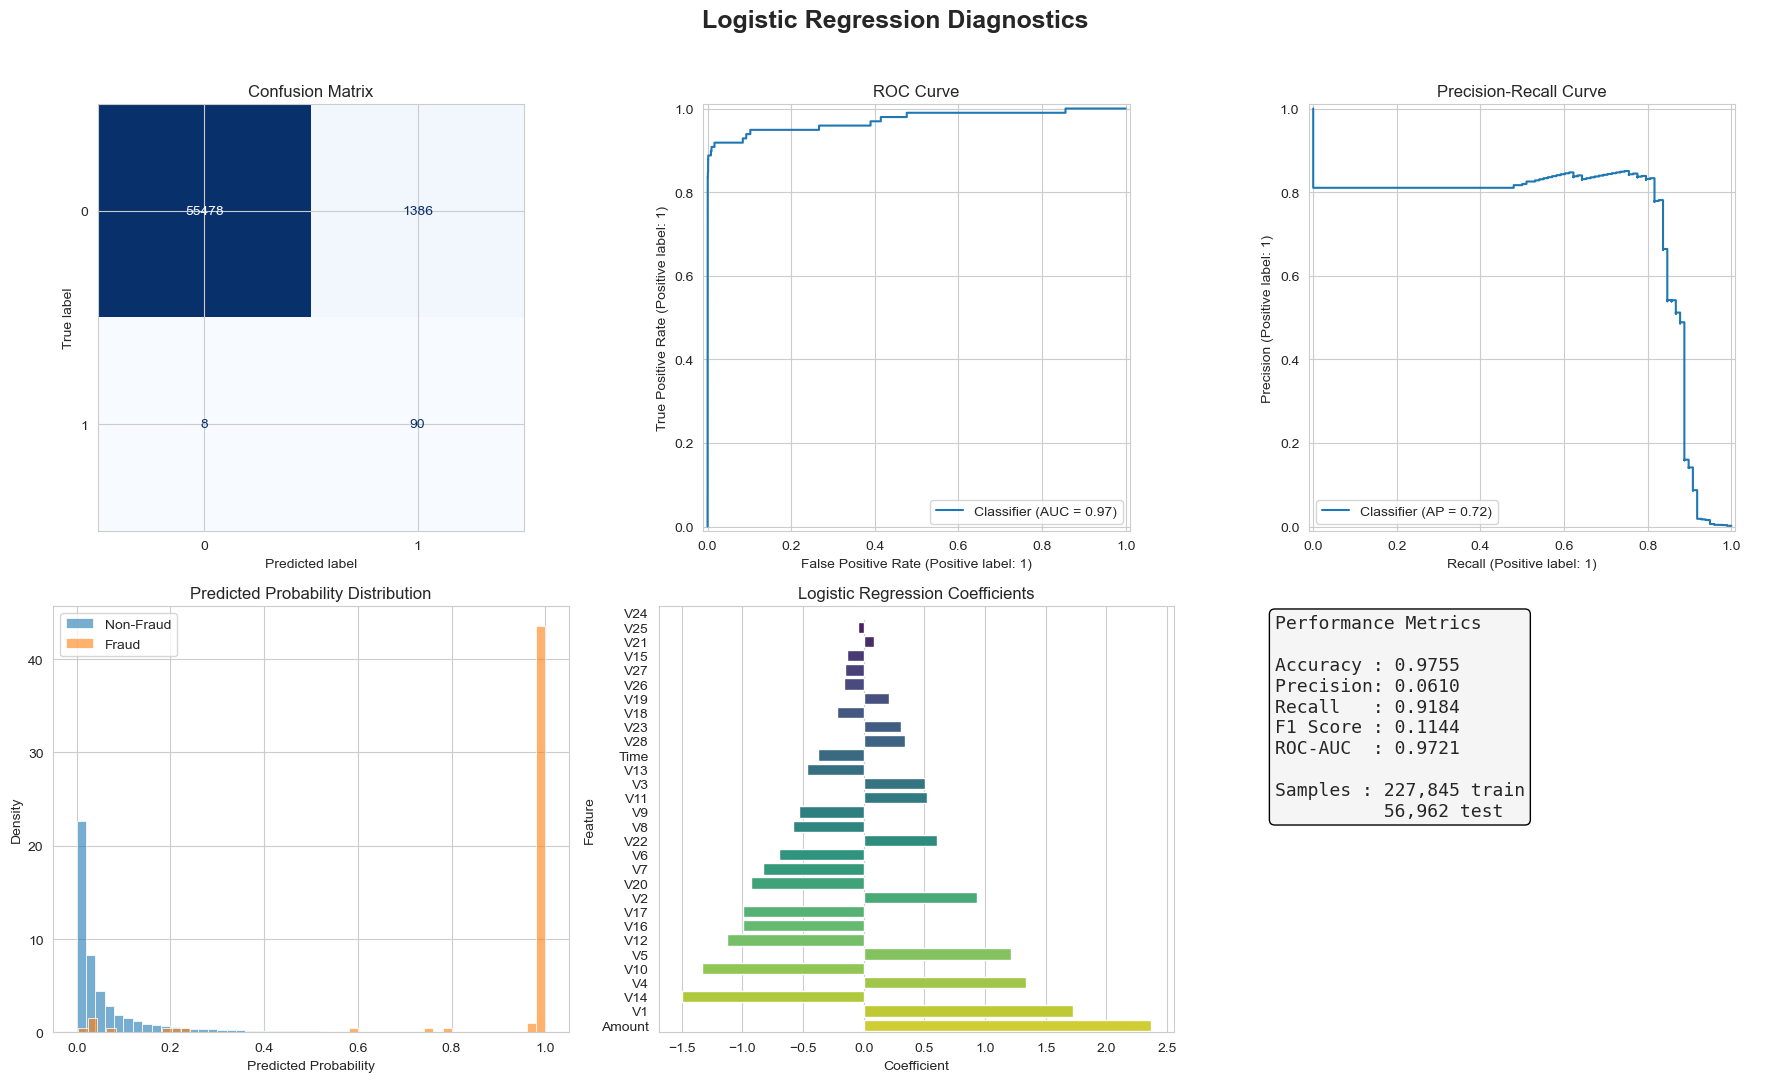

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

# ==========================================================
# Prepare Data
# ==========================================================

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ==========================================================
# Build Pipeline
# ==========================================================

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# ==========================================================
# Train Model
# ==========================================================

pipe.fit(X_train, y_train)

# ==========================================================
# Predictions
# ==========================================================

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:,1]

# ==========================================================
# Metrics
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("="*60)
print("Logistic Regression Performance")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# ==========================================================
# Feature Importance
# ==========================================================

feature_names = X_train.columns

coef = pipe.named_steps["logreg"].coef_[0]

importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coef,
        "AbsCoeff": np.abs(coef)
    })
    .sort_values("AbsCoeff", ascending=True)
)

# ==========================================================
# Plotting
# ==========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,11)
)

# ----------------------------------------------------------
# 1. Confusion Matrix
# ----------------------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    colorbar=False,
    ax=axes[0,0]
)

axes[0,0].set_title("Confusion Matrix")

# ----------------------------------------------------------
# 2. ROC Curve
# ----------------------------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=axes[0,1]
)

axes[0,1].set_title("ROC Curve")

# ----------------------------------------------------------
# 3. Precision-Recall Curve
# ----------------------------------------------------------

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob,
    ax=axes[0,2]
)

axes[0,2].set_title("Precision-Recall Curve")

# ----------------------------------------------------------
# 4. Probability Distribution
# ----------------------------------------------------------

sns.histplot(
    y_prob[y_test==0],
    bins=50,
    stat="density",
    alpha=0.6,
    label="Non-Fraud",
    ax=axes[1,0]
)

sns.histplot(
    y_prob[y_test==1],
    bins=50,
    stat="density",
    alpha=0.6,
    label="Fraud",
    ax=axes[1,0]
)

axes[1,0].set_xlabel("Predicted Probability")
axes[1,0].set_ylabel("Density")
axes[1,0].set_title("Predicted Probability Distribution")
axes[1,0].legend()

# ----------------------------------------------------------
# 5. Feature Importance
# ----------------------------------------------------------

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=axes[1,1]
)

axes[1,1].set_title("Logistic Regression Coefficients")
axes[1,1].set_xlabel("Coefficient")

# ----------------------------------------------------------
# 6. Performance Summary
# ----------------------------------------------------------

axes[1,2].axis("off")

summary = (
    "Performance Metrics\n\n"
    f"Accuracy : {accuracy:.4f}\n"
    f"Precision: {precision:.4f}\n"
    f"Recall   : {recall:.4f}\n"
    f"F1 Score : {f1:.4f}\n"
    f"ROC-AUC  : {roc_auc:.4f}\n\n"
    f"Samples : {len(X_train):,} train\n"
    f"          {len(X_test):,} test"
)

axes[1,2].text(
    0.02,
    0.98,
    summary,
    fontsize=13,
    family="monospace",
    va="top",
    bbox=dict(
        boxstyle="round",
        facecolor="whitesmoke",
        edgecolor="black"
    )
)

plt.suptitle(
    "Logistic Regression Diagnostics",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.savefig(
    "../figures/logistic_regression_diagnostics.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# <font color='orange'> K-Nearest Neighbours </font>

## <font color='blue'> This will take forever to run. </font>

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier

# from sklearn.model_selection import (
#     train_test_split,
#     RandomizedSearchCV,
#     cross_val_score
# )

# from sklearn.metrics import (
#     accuracy_score,
#     balanced_accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     average_precision_score,
#     confusion_matrix,
#     ConfusionMatrixDisplay,
#     RocCurveDisplay,
#     PrecisionRecallDisplay,
#     classification_report
# )

# # =====================================================
# # Prepare Data
# # =====================================================

# X = df.drop("Class", axis=1)
# y = df["Class"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.20,
#     stratify=y,
#     random_state=42
# )

# # =====================================================
# # Pipeline
# # =====================================================

# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("knn", KNeighborsClassifier())
# ])

# # =====================================================
# # Randomized Search (Much Faster)
# # =====================================================

# param_dist = {
#     "knn__n_neighbors":[3,5,7,9,11,15],
#     "knn__weights":["uniform","distance"],
#     "knn__metric":["euclidean","manhattan"]
# }

# search = RandomizedSearchCV(
#     pipe,
#     param_distributions=param_dist,
#     n_iter=8,
#     cv=3,
#     scoring="f1",
#     random_state=42,
#     n_jobs=-1
# )

# search.fit(X_train,y_train)

# pipe = search.best_estimator_

# print(search.best_params_)

# # =====================================================
# # Predictions
# # =====================================================

# y_pred = pipe.predict(X_test)
# y_prob = pipe.predict_proba(X_test)[:,1]

# # =====================================================
# # Metrics
# # =====================================================

# accuracy = accuracy_score(y_test,y_pred)
# balanced_accuracy = balanced_accuracy_score(y_test,y_pred)
# precision = precision_score(y_test,y_pred)
# recall = recall_score(y_test,y_pred)
# f1 = f1_score(y_test,y_pred)
# roc_auc = roc_auc_score(y_test,y_prob)
# pr_auc = average_precision_score(y_test,y_prob)

# print(classification_report(y_test,y_pred))

# cm = confusion_matrix(y_test,y_pred)
# tn,fp,fn,tp = cm.ravel()

# # =====================================================
# # Small Validation Plot
# # =====================================================

# k_values = [3,5,7,9,11]

# scores = []

# for k in k_values:

#     model = Pipeline([
#         ("scaler",StandardScaler()),
#         ("knn",KNeighborsClassifier(
#             n_neighbors=k,
#             weights="distance"
#         ))
#     ])

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=3,
#         scoring="balanced_accuracy",
#         n_jobs=-1
#     ).mean()

#     scores.append(score)

# # =====================================================
# # Plotting
# # =====================================================

# sns.set_style("whitegrid")

# fig,axes=plt.subplots(2,3,figsize=(18,11))

# ConfusionMatrixDisplay.from_predictions(
#     y_test,
#     y_pred,
#     cmap="Blues",
#     colorbar=False,
#     ax=axes[0,0]
# )

# axes[0,0].set_title("Confusion Matrix")

# RocCurveDisplay.from_predictions(
#     y_test,
#     y_prob,
#     ax=axes[0,1]
# )

# axes[0,1].set_title("ROC Curve")

# PrecisionRecallDisplay.from_predictions(
#     y_test,
#     y_prob,
#     ax=axes[0,2]
# )

# axes[0,2].set_title("Precision-Recall Curve")

# sns.histplot(
#     y_prob[y_test==0],
#     bins=40,
#     stat="density",
#     alpha=0.6,
#     label="Non-Fraud",
#     ax=axes[1,0]
# )

# sns.histplot(
#     y_prob[y_test==1],
#     bins=40,
#     stat="density",
#     alpha=0.6,
#     label="Fraud",
#     ax=axes[1,0]
# )

# axes[1,0].legend()
# axes[1,0].set_title("Predicted Probability")

# axes[1,1].plot(
#     k_values,
#     scores,
#     marker="o",
#     linewidth=2
# )

# axes[1,1].set_xlabel("k")
# axes[1,1].set_ylabel("Balanced Accuracy")
# axes[1,1].set_title("Cross Validation")

# axes[1,2].axis("off")

# summary = (
# f"Best Parameters\n\n"
# f"k = {pipe.named_steps['knn'].n_neighbors}\n"
# f"Weights = {pipe.named_steps['knn'].weights}\n"
# f"Metric = {pipe.named_steps['knn'].metric}\n\n"
# f"Accuracy = {accuracy:.4f}\n"
# f"Balanced Accuracy = {balanced_accuracy:.4f}\n"
# f"Precision = {precision:.4f}\n"
# f"Recall = {recall:.4f}\n"
# f"F1 = {f1:.4f}\n"
# f"ROC-AUC = {roc_auc:.4f}\n"
# f"PR-AUC = {pr_auc:.4f}\n\n"
# f"TN={tn}\n"
# f"FP={fp}\n"
# f"FN={fn}\n"
# f"TP={tp}"
# )

# axes[1,2].text(
#     0.02,
#     0.98,
#     summary,
#     va="top",
#     fontsize=12,
#     family="monospace",
#     bbox=dict(
#         boxstyle="round",
#         facecolor="whitesmoke"
#     )
# )

# plt.suptitle(
#     "K-Nearest Neighbours Diagnostics",
#     fontsize=18,
#     fontweight="bold"
# )

# plt.tight_layout(rect=[0,0,1,0.96])

# plt.savefig(
#     "../figures/knn_diagnostics.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

## <font color='orange'> Support Vector Machine </font>


Best Parameters
{'svm__estimator__C': 0.01}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.58      0.67        98

    accuracy                           1.00     56962
   macro avg       0.90      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



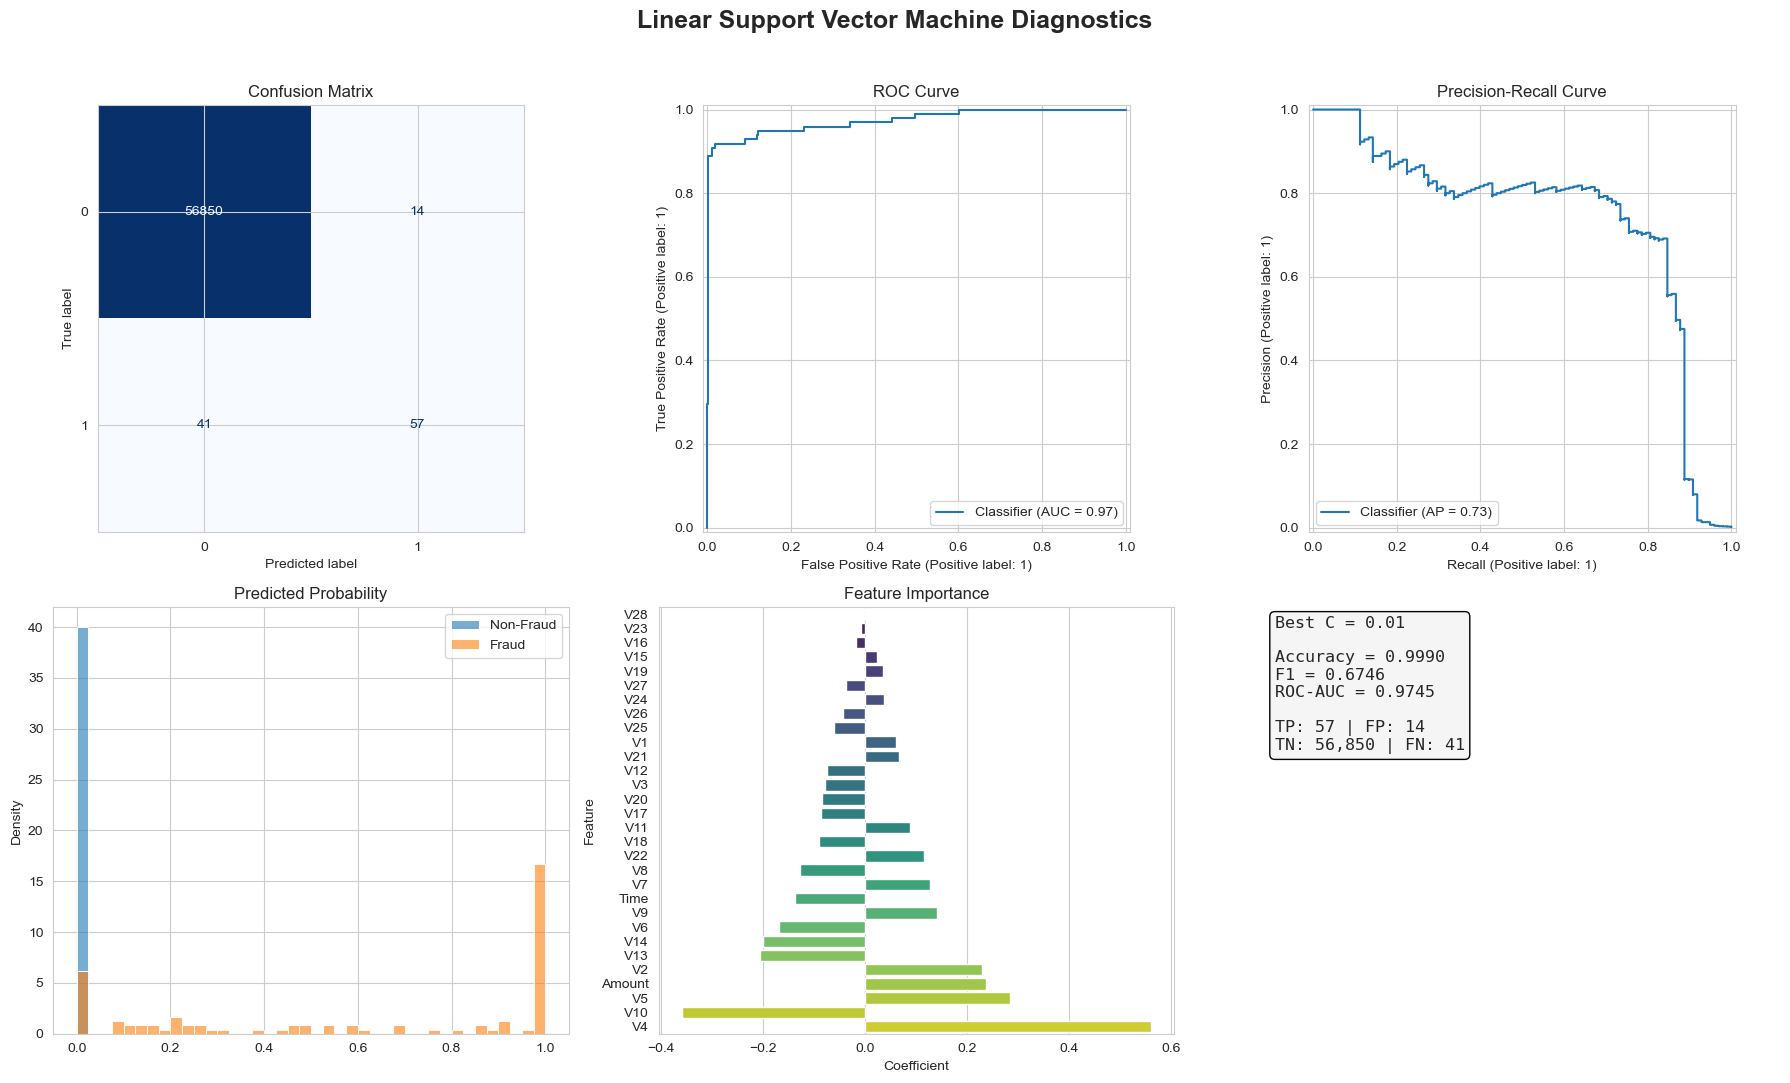

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, average_precision_score, 
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, 
    PrecisionRecallDisplay, classification_report
)

# =====================================================
# Prepare Data
# =====================================================
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# =====================================================
# Pipeline
# =====================================================
base_svm = LinearSVC(
    class_weight="balanced",
    dual=False,
    max_iter=5000,
    random_state=42
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    cv=3
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", calibrated_svm)
])

# =====================================================
# Hyperparameter Search
# =====================================================
param_grid = {
    "svm__estimator__C": [0.01, 0.1, 1, 10]
}

grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=4,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

grid.fit(X_train, y_train)
pipe = grid.best_estimator_

print("\nBest Parameters")
print(grid.best_params_)

# =====================================================
# Predictions
# =====================================================
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

# =====================================================
# Metrics
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(classification_report(y_test, y_pred))

# =====================================================
# Feature Importance (Fixed)
# =====================================================
# Accessing the underlying estimator from the first fold
coef = pipe.named_steps["svm"].calibrated_classifiers_[0].estimator.coef_[0]

importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coef,
        "AbsCoeff": np.abs(coef)
    })
    .sort_values("AbsCoeff", ascending=True)
)

# =====================================================
# Plotting
# =====================================================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix")

# 2. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0, 1])
axes[0, 1].set_title("ROC Curve")

# 3. Precision Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[0, 2])
axes[0, 2].set_title("Precision-Recall Curve")

# 4. Probability Distribution
sns.histplot(y_prob[y_test == 0], bins=40, stat="density", alpha=0.6, label="Non-Fraud", ax=axes[1, 0])
sns.histplot(y_prob[y_test == 1], bins=40, stat="density", alpha=0.6, label="Fraud", ax=axes[1, 0])
axes[1, 0].legend()
axes[1, 0].set_title("Predicted Probability")

# 5. Feature Ranking
sns.barplot(data=importance, x="Coefficient", y="Feature", hue="Feature", 
            dodge=False, palette="viridis", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Feature Importance")

# 6. Performance Summary
axes[1, 2].axis("off")
summary = (
    f"Best C = {grid.best_params_['svm__estimator__C']}\n\n"
    f"Accuracy = {accuracy:.4f}\n"
    f"F1 = {f1:.4f}\n"
    f"ROC-AUC = {roc_auc:.4f}\n\n"
    f"TP: {tp:,} | FP: {fp:,}\n"
    f"TN: {tn:,} | FN: {fn:,}"
)
axes[1, 2].text(0.02, 0.98, summary, fontsize=12, family="monospace", va="top",
                bbox=dict(boxstyle="round", facecolor="whitesmoke", edgecolor="black"))

plt.suptitle("Linear Support Vector Machine Diagnostics", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../figures/linear_svm_diagnostics.pdf", dpi=300, bbox_inches="tight")
plt.show()

## <font color='orange'> Random Forest </font>


Best Parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 5, 'rf__max_features': 'sqrt', 'rf__max_depth': 20}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.94      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



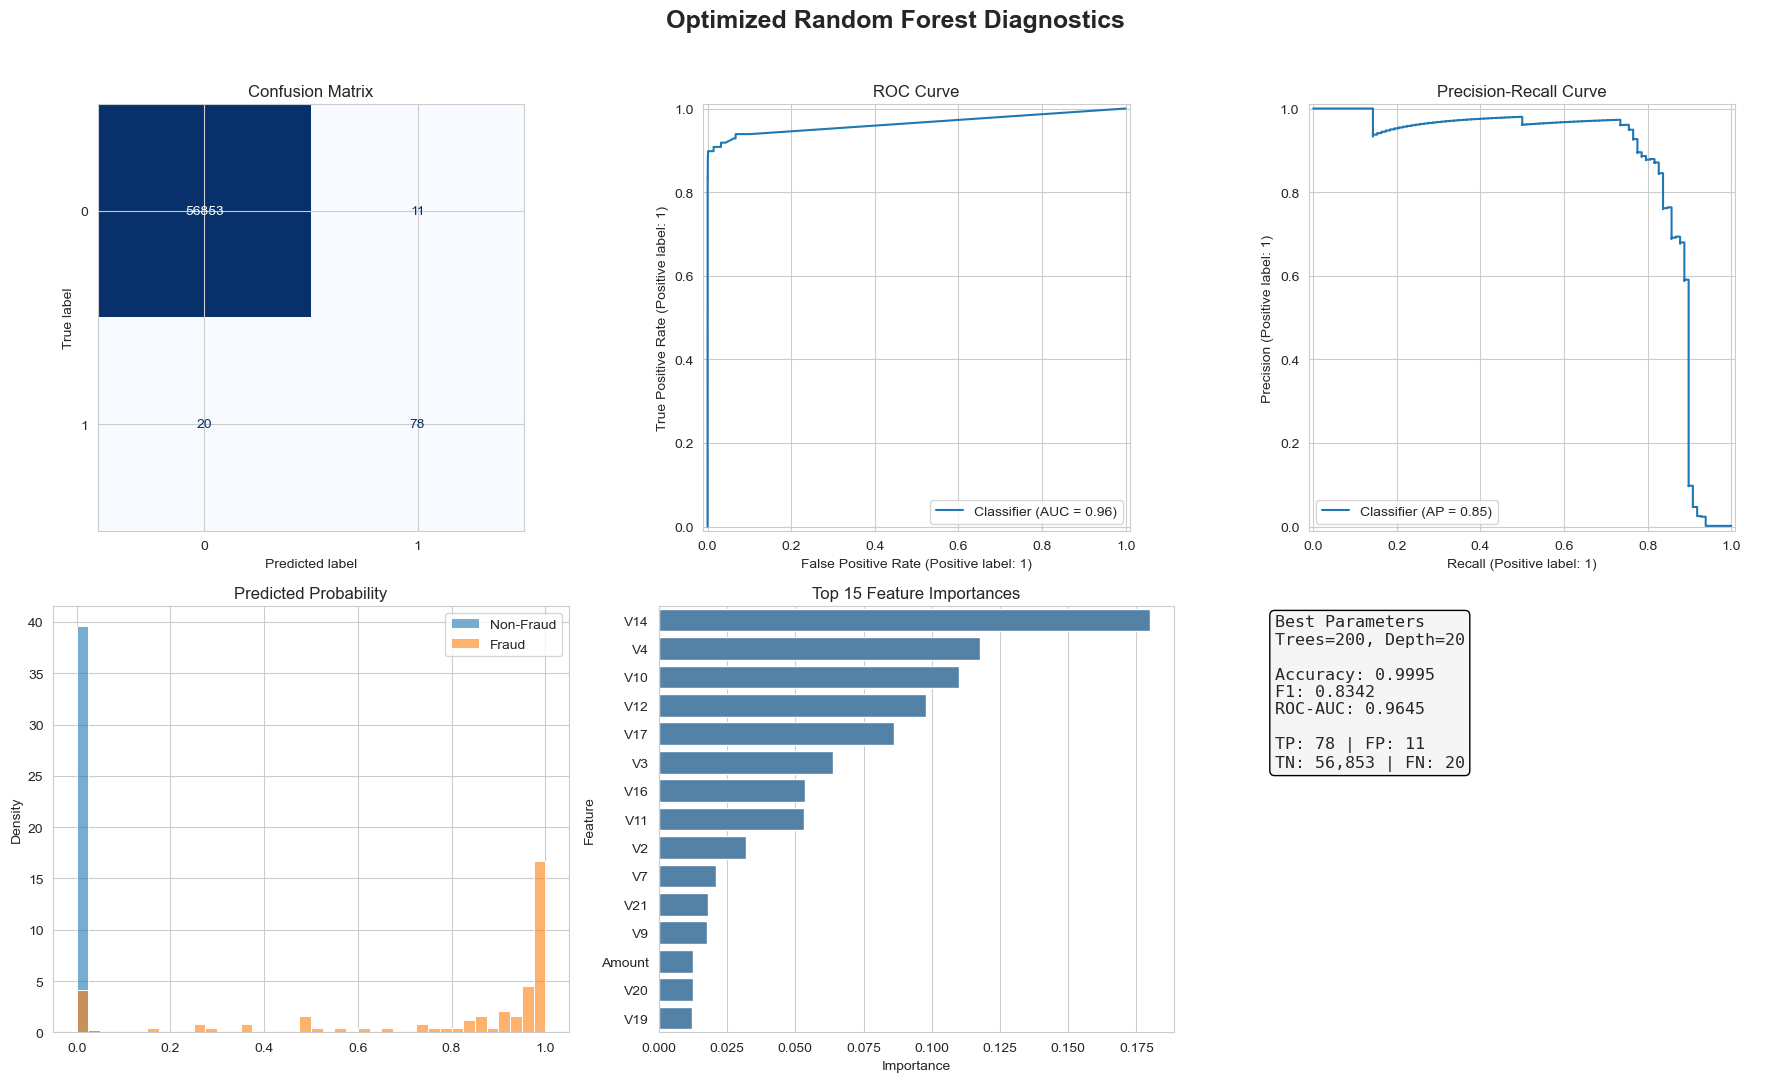

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, average_precision_score, 
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, 
    PrecisionRecallDisplay, classification_report
)

# =====================================================
# Prepare Data
# =====================================================
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# =====================================================
# Pipeline (Scaler removed: RF is scale-invariant)
# =====================================================
# Set n_jobs=1 here to avoid CPU contention
pipe = Pipeline([
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=1 
    ))
])

# =====================================================
# Hyperparameter Search
# =====================================================
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [5, 10, 20],
    "rf__min_samples_split": [5, 10],
    "rf__max_features": ["sqrt"] # "log2" is often slower/less effective
}

# n_jobs=-1 parallelizes the CV folds, which is much faster
grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=8, 
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1 
)

grid.fit(X_train, y_train)
pipe = grid.best_estimator_

print(f"\nBest Parameters: {grid.best_params_}")

# =====================================================
# Predictions
# =====================================================
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

# =====================================================
# Metrics
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(classification_report(y_test, y_pred))

# =====================================================
# Feature Importance
# =====================================================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": pipe.named_steps["rf"].feature_importances_
}).sort_values("Importance", ascending=False).head(15)

# =====================================================
# Plotting
# =====================================================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plots
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0, 1])
axes[0, 1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[0, 2])
axes[0, 2].set_title("Precision-Recall Curve")

sns.histplot(y_prob[y_test == 0], bins=40, stat="density", alpha=0.6, label="Non-Fraud", ax=axes[1, 0])
sns.histplot(y_prob[y_test == 1], bins=40, stat="density", alpha=0.6, label="Fraud", ax=axes[1, 0])
axes[1, 0].set_title("Predicted Probability")
axes[1, 0].legend()

sns.barplot(data=importance, x="Importance", y="Feature", color="steelblue", ax=axes[1, 1])
axes[1, 1].set_title("Top 15 Feature Importances")

# Summary
axes[1, 2].axis("off")
summary = (
    f"Best Parameters\n"
    f"Trees={pipe.named_steps['rf'].n_estimators}, Depth={pipe.named_steps['rf'].max_depth}\n\n"
    f"Accuracy: {accuracy:.4f}\nF1: {f1:.4f}\nROC-AUC: {roc_auc:.4f}\n\n"
    f"TP: {tp:,} | FP: {fp:,}\n"
    f"TN: {tn:,} | FN: {fn:,}"
)
axes[1, 2].text(0.02, 0.98, summary, fontsize=12, family="monospace", va="top",
                bbox=dict(boxstyle="round", facecolor="whitesmoke", edgecolor="black"))

plt.suptitle("Optimized Random Forest Diagnostics", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../figures/rf_diagnostics_optimized.pdf", dpi=300, bbox_inches="tight")
plt.show()

## <font color='orange'> Boosted Decision Tree </font>


Best Parameters: {'gbc__subsample': 0.8, 'gbc__n_estimators': 100, 'gbc__max_depth': 5, 'gbc__learning_rate': 0.01}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.74      0.83        98

    accuracy                           1.00     56962
   macro avg       0.97      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



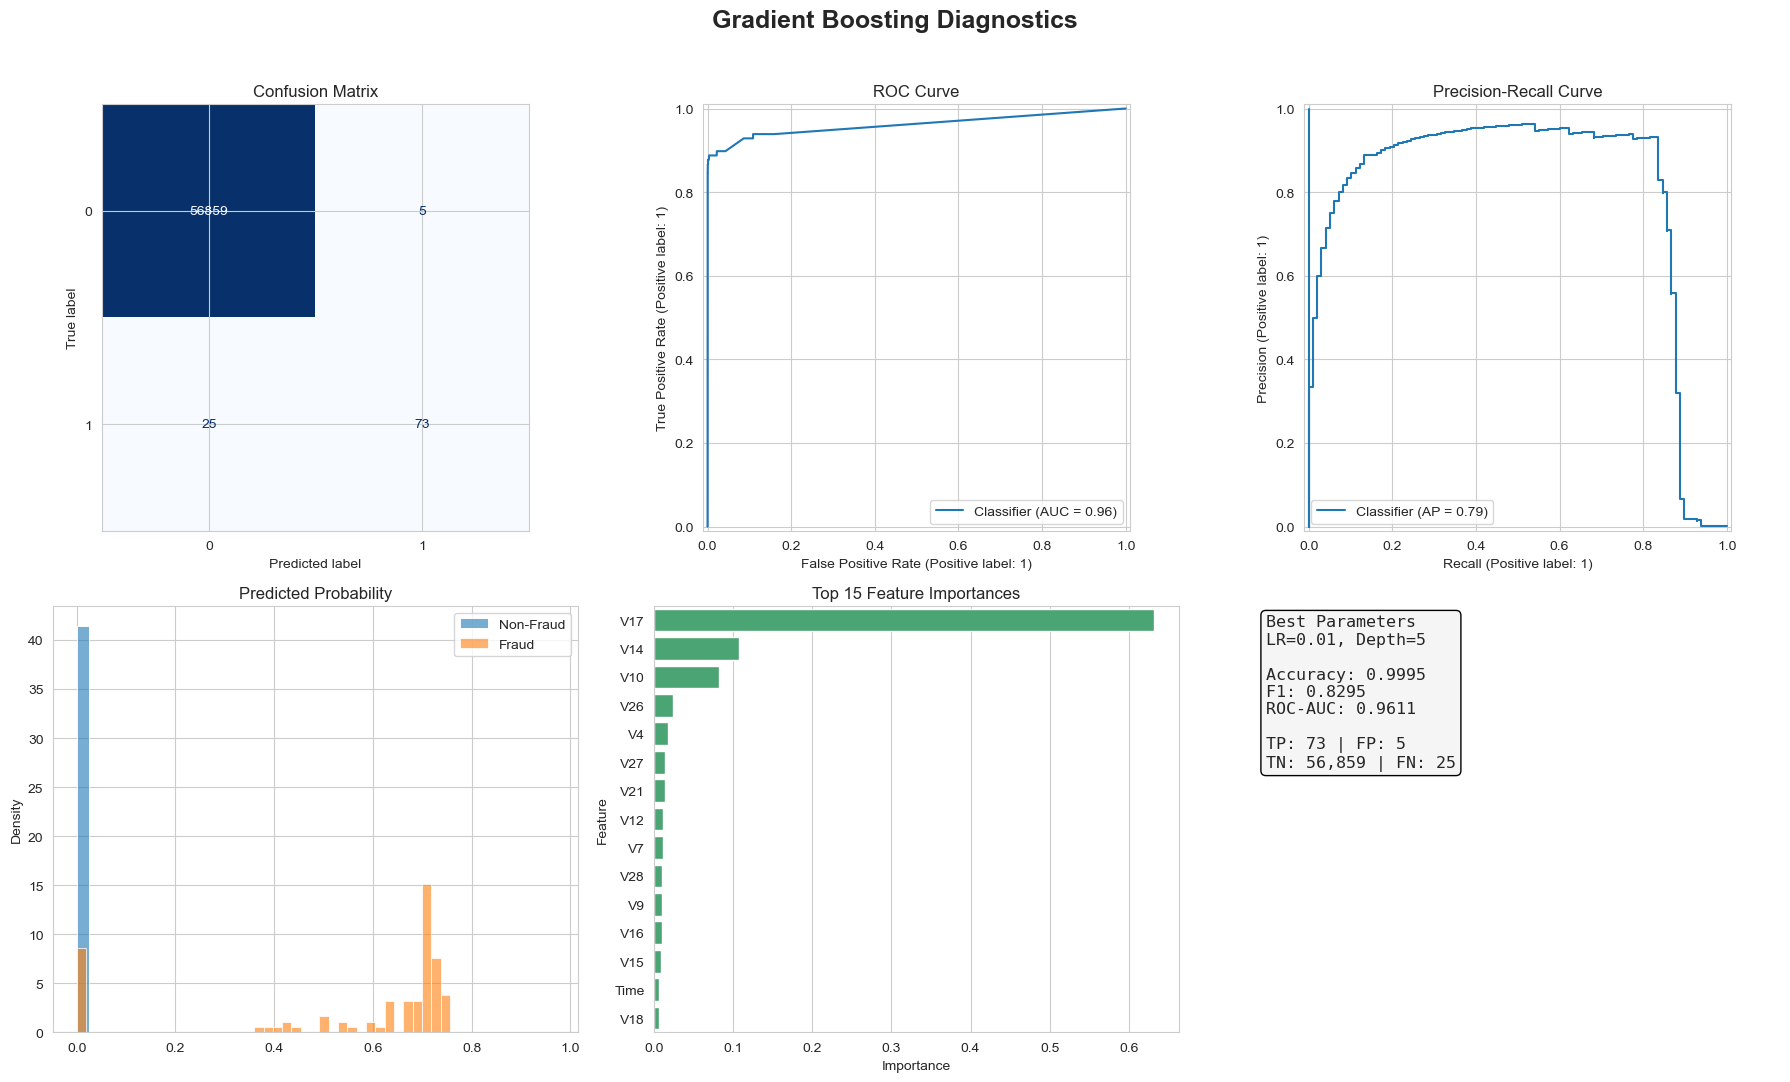

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, average_precision_score, 
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, 
    PrecisionRecallDisplay, classification_report
)

# =====================================================
# Prepare Data
# =====================================================
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# =====================================================
# Pipeline
# =====================================================
# n_iter_no_change enables Early Stopping for speed
pipe = Pipeline([
    ("gbc", GradientBoostingClassifier(
        random_state=42,
        n_iter_no_change=10, 
        validation_fraction=0.1
    ))
])

# =====================================================
# Hyperparameter Search
# =====================================================
param_grid = {
    "gbc__n_estimators": [100, 200, 300],
    "gbc__learning_rate": [0.01, 0.05, 0.1],
    "gbc__max_depth": [3, 4, 5],
    "gbc__subsample": [0.8, 1.0]
}

grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

grid.fit(X_train, y_train)
pipe = grid.best_estimator_

print(f"\nBest Parameters: {grid.best_params_}")

# =====================================================
# Predictions
# =====================================================
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

# =====================================================
# Metrics
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(classification_report(y_test, y_pred))

# =====================================================
# Feature Importance
# =====================================================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": pipe.named_steps["gbc"].feature_importances_
}).sort_values("Importance", ascending=False).head(15)

# =====================================================
# Plotting
# =====================================================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plots
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0, 1])
axes[0, 1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[0, 2])
axes[0, 2].set_title("Precision-Recall Curve")

sns.histplot(y_prob[y_test == 0], bins=40, stat="density", alpha=0.6, label="Non-Fraud", ax=axes[1, 0])
sns.histplot(y_prob[y_test == 1], bins=40, stat="density", alpha=0.6, label="Fraud", ax=axes[1, 0])
axes[1, 0].set_title("Predicted Probability")
axes[1, 0].legend()

sns.barplot(data=importance, x="Importance", y="Feature", color="mediumseagreen", ax=axes[1, 1])
axes[1, 1].set_title("Top 15 Feature Importances")

# Summary
axes[1, 2].axis("off")
summary = (
    f"Best Parameters\n"
    f"LR={grid.best_params_['gbc__learning_rate']}, Depth={grid.best_params_['gbc__max_depth']}\n\n"
    f"Accuracy: {accuracy:.4f}\nF1: {f1:.4f}\nROC-AUC: {roc_auc:.4f}\n\n"
    f"TP: {tp:,} | FP: {fp:,}\n"
    f"TN: {tn:,} | FN: {fn:,}"
)
axes[1, 2].text(0.02, 0.98, summary, fontsize=12, family="monospace", va="top",
                bbox=dict(boxstyle="round", facecolor="whitesmoke", edgecolor="black"))

plt.suptitle("Gradient Boosting Diagnostics", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../figures/gbc_diagnostics.pdf", dpi=300, bbox_inches="tight")
plt.show()

## <font color='orange'> Stacked Classifier </font>


Best Parameters: {'stacking__rf__max_depth': 10, 'stacking__gbc__max_depth': 3, 'stacking__gbc__learning_rate': 0.1, 'stacking__final_estimator__C': 1.0}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.71      0.81        98

    accuracy                           1.00     56962
   macro avg       0.97      0.86      0.91     56962
weighted avg       1.00      1.00      1.00     56962



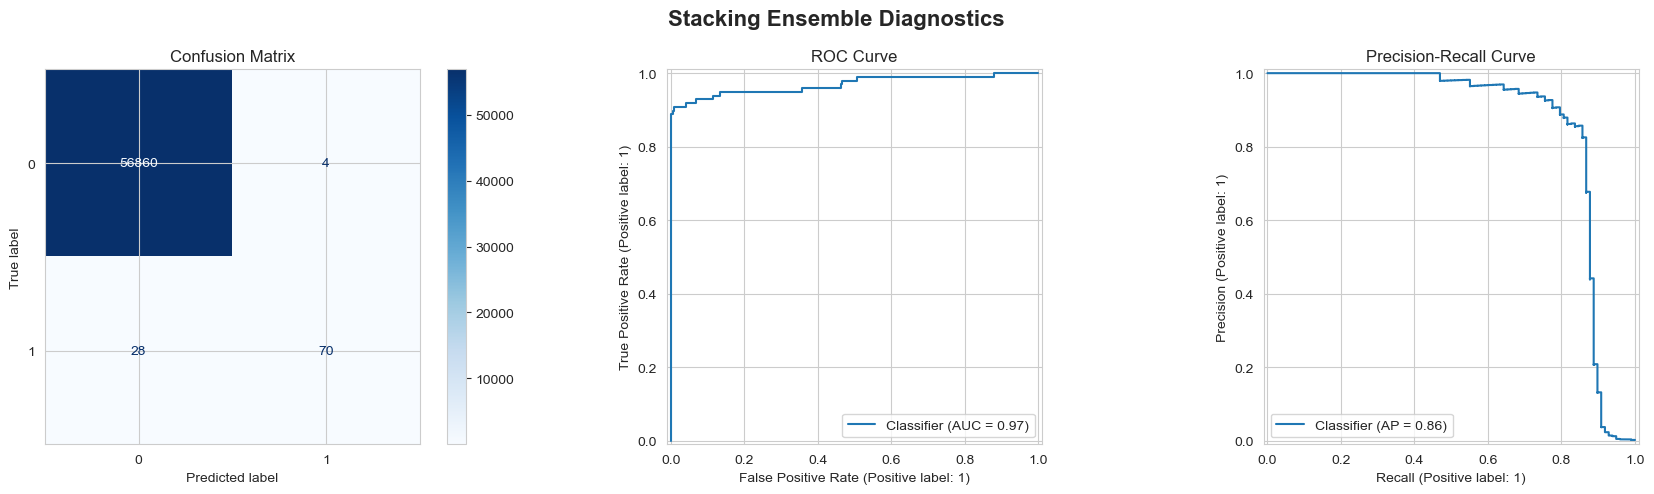

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, average_precision_score, 
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, 
    PrecisionRecallDisplay, classification_report
)

# =====================================================
# Prepare Data
# =====================================================
# Ensure 'df' is loaded in your environment
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# =====================================================
# Stacking Ensemble Setup
# =====================================================
# We increase max_iter for Logistic Regression to ensure convergence
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('gbc', GradientBoostingClassifier(n_iter_no_change=10, validation_fraction=0.1, random_state=42)),
    ('lr', LogisticRegression(max_iter=2000, random_state=42))
]

# Stacking Classifier with Logistic Regression as the final meta-model
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5,
    n_jobs=-1
)

# Pipeline: Scale data first, then feed into the Stack
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("stacking", stacking_clf)
])

# =====================================================
# Hyperparameter Search
# =====================================================
param_grid = {
    "stacking__gbc__learning_rate": [0.01, 0.05, 0.1],
    "stacking__gbc__max_depth": [3, 4],
    "stacking__rf__max_depth": [5, 10, None],
    "stacking__final_estimator__C": [0.01, 0.1, 1.0]
}

grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_pipe = grid.best_estimator_

print(f"\nBest Parameters: {grid.best_params_}")

# =====================================================
# Predictions
# =====================================================
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =====================================================
# Visualizations
# =====================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("ROC Curve")

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.suptitle("Stacking Ensemble Diagnostics", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Logistic regression seem to perform better than all the other scenarios.